In [3]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"         # better stacktraces if CUDA errors
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # more deterministic matmuls (optional)

import torch, sys
print("torch:", torch.__version__, "cuda:", torch.version.cuda)
print("available:", torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
torch: 2.8.0+cu128 cuda: 12.8
available: True


In [4]:
# Paths
from pathlib import Path

REPO = Path("/nfs/team361/mv11/GGSD")   # repo root
assert REPO.exists(), f"Repo not found: {REPO}"

# New experiment root for QM9
EXP  = Path("/nfs/team361/mv11/scgg-reproducibility/experiments/ggsd/01_qm9_baseline")
FIG  = EXP/"figs";        FIG.mkdir(parents=True, exist_ok=True)
CKPT = EXP/"checkpoints"; CKPT.mkdir(parents=True, exist_ok=True)
SMP  = EXP/"samples";     SMP.mkdir(parents=True, exist_ok=True)
LOGS = EXP/"logs";        LOGS.mkdir(parents=True, exist_ok=True)

print("EXP:", EXP)


EXP: /nfs/team361/mv11/scgg-reproducibility/experiments/ggsd/01_qm9_baseline


In [3]:
# One-time deps (idempotent). RDKit is needed for molecular viz/metrics.
!pip -q install "diffusers==0.21.4" "huggingface_hub==0.19.4" rdkit-pypi >/dev/null
print("ok")


DEPRECATION: lightning-lite 1.8.0 has a non-standard dependency specifier torch>=1.9.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of lightning-lite or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
DEPRECATION: pytorch-lightning 1.8.0 has a non-standard dependency specifier torch>=1.9.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pytorch-lightning or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
ok


## Load QM9

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch.serialization as ts

import sys
sys.path.append(str(REPO))

from dataset.load_data_generated import LaplacianDatasetNX

DATASET  = "qm9"
K        = 16          # eigenpairs to use first (paper used small k; you can scale later)
SMALLEST = False       # you can flip later to compare smallest vs largest
SCALER   = "standard"  # matches paper
NODEFEAT = True        # QM9 has node/edge labels

ds_stem  = str(REPO/"data"/DATASET)  # points to .../GGSD/data/qm9 (no .pkl)
assert Path(ds_stem + ".pkl").exists(), f"Missing: {ds_stem+'.pkl'}"


In [4]:


# # Allowlist NumPy scalar used in the saved cache so torch.load() can unpickle it safely
# ts.add_safe_globals([np.core.multiarray.scalar])


# splits like your proteins run
train_set = LaplacianDatasetNX(DATASET, ds_stem, point_dim=K, smallest=SMALLEST,
                               split='train_train', scaler=SCALER,
                               nodefeatures=NODEFEAT, device="cpu")
val_set   = LaplacianDatasetNX(DATASET, ds_stem, point_dim=K, smallest=SMALLEST,
                               split='train_val', scaler=SCALER,
                               nodefeatures=NODEFEAT, device="cpu")
test_set  = LaplacianDatasetNX(DATASET, ds_stem, point_dim=K, smallest=SMALLEST,
                               split='test',       scaler=SCALER,
                               nodefeatures=NODEFEAT, device="cpu")

print("len(train), len(val), len(test):", len(train_set), len(val_set), len(test_set))

# Peek a sample: (evecs, evals, node_mask, eig_mask, edge_feats?, laplacian?, n?)
s = train_set[0]
for i, t in enumerate(s):
    try:
        print(f"[{i}] shape:", tuple(t.shape))
    except Exception:
        print(f"[{i}] type:", type(t))


len(train), len(val), len(test): 83730 20933 26165
[0] shape: (9, 20)
[1] shape: (20,)
[2] shape: (9,)
[3] shape: (20,)


In [7]:
# cache heavy/padded stuff once; switch off later if you only need spectra
train_set.get_extra_data(True)
val_set.get_extra_data(True)
test_set.get_extra_data(True)

print("n_max (pad size):", train_set.n_max)


n_max (pad size): 9


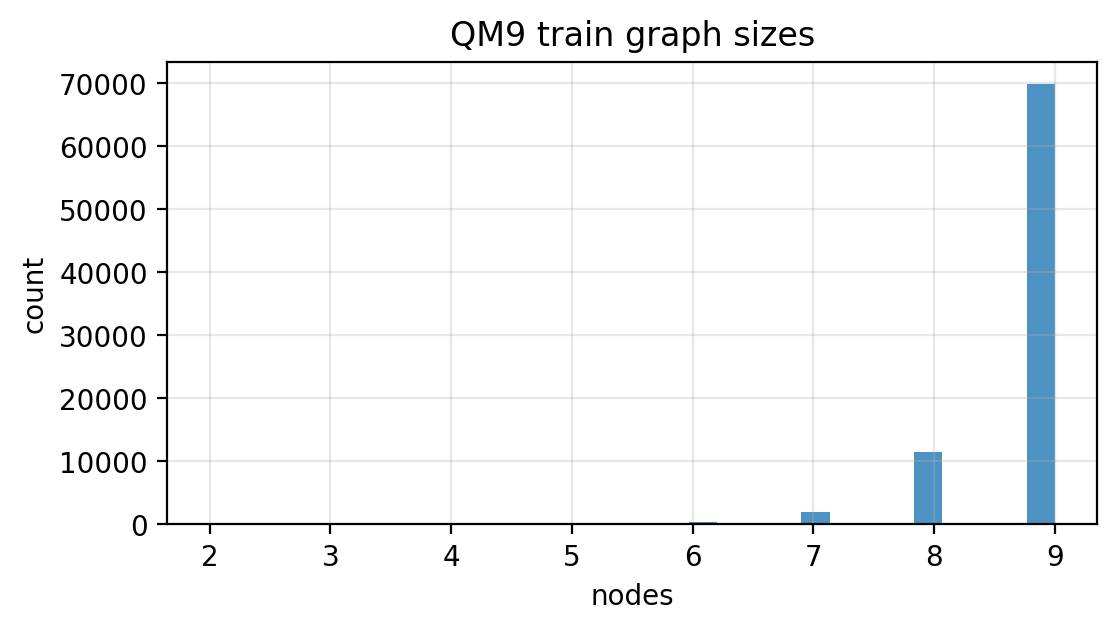

avg n: 8.797002269198614 min: 2 max: 9


In [8]:
# size histogram + average nodes
sizes = [int(x[-2]) if hasattr(x[-2], "item") else int(x[-2]) for x in train_set]  # repo stores n in sample[-2]
plt.figure(figsize=(6,3))
plt.hist(sizes, bins=30, alpha=0.8)
plt.title("QM9 train graph sizes"); plt.xlabel("nodes"); plt.ylabel("count"); plt.grid(alpha=.3)
plt.show()

print("avg n:", float(np.mean(sizes)), "min:", int(np.min(sizes)), "max:", int(np.max(sizes)))


In [9]:
# feature sizes
phi, lam, nmask, emask = train_set[0][0], train_set[0][1], train_set[0][2], train_set[0][3]
feature_size = phi.shape[-1] - K
print("K:", K, "feature_size (extra node-channels):", feature_size)
assert feature_size >= 0


K: 16 feature_size (extra node-channels): 4


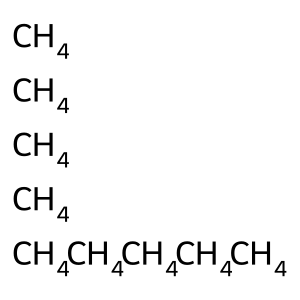

In [10]:
import torch, networkx as nx
from rdkit import Chem
from rdkit.Chem import Draw

def unscale_xy(ds, evec, eval_):
    # the dataset exposes callables too, but this helper keeps it explicit
    return ds.unscale_xy(evec, eval_)

ATOM_MAP = {0: 'C', 1: 'N', 2: 'O', 3: 'F'}
BOND_MAP = {
    0: Chem.rdchem.BondType.SINGLE,
    1: Chem.rdchem.BondType.DOUBLE,
    2: Chem.rdchem.BondType.TRIPLE
}

def mol_from_adj_and_feats(adj01, node_onehot, edge_onehot):
    """Build an RDKit Mol from adjacency (0/1), node onehot [N,4], edge onehot [N,N,3]."""
    mol = Chem.RWMol()
    idx_to_atom = []
    for i in range(node_onehot.shape[0]):
        atom_idx = int(node_onehot[i].argmax().item())
        sym = ATOM_MAP.get(atom_idx, 'C')
        a = Chem.Atom(sym)
        idx_to_atom.append(mol.AddAtom(a))
    N = adj01.shape[0]
    for i in range(N):
        for j in range(i+1, N):
            if adj01[i, j] > 0.5:
                bt = int(edge_onehot[i, j].argmax().item())
                mol.AddBond(i, j, BOND_MAP.get(bt, Chem.rdchem.BondType.SINGLE))
    return mol.GetMol()

# pick a sample molecule
ii = 0
evec = train_set[ii][0].clone()        # (N, K+feat)
eval_ = train_set[ii][1].clone()       # (K+feat,)
Lpad = train_set[ii][-1][0].clone()    # (N_max, N_max)
n = int(train_set[ii][-2])             # true nodes
edge_feat = train_set[ii][4].clone()   # (N, N, 3) on QM9

# crop to n and form adjacency
L = Lpad[:n, :n]
A = (-L).cpu().numpy()
np.fill_diagonal(A, 0.0)
A = (A > 0).astype(float)

# split Φ into eigenvectors + node-feat channels, then argmax for atoms
evec_u, eval_u = unscale_xy(train_set, evec, eval_)
node_feat_onehot = evec_u[:, K:]  # (N, 4) one-hot-ish
node_feat_onehot = torch.nn.functional.one_hot(node_feat_onehot.argmax(-1), num_classes=4).float()

mol = mol_from_adj_and_feats(A, node_feat_onehot.cpu(), edge_feat[:n, :n].cpu())
img = Draw.MolToImage(mol, size=(300, 300))
display(img)


In [6]:
import torch
import numpy as np

def orthogonality_error(phi, em=None):
    """|| Φ^T Φ - I ||_F / k  on active dims (uses only eigen part, not node-feat channels)."""
    k = min(K, phi.shape[1])
    Phi = phi[:, :k]
    G = Phi.T @ Phi
    return torch.norm(G - torch.eye(k, device=Phi.device), p='fro').item() / max(1, k)

def degree_integrality(phi, lam):
    """For unnormalized L, diag(L) ≈ degrees (integers). QM9 preprocessing may be normalized;
       treat this as a soft heuristic only."""
    L = (phi * lam[None, :K]) @ phi[:, :K].t()
    d  = L.diag().cpu().numpy()
    return float(np.mean(np.abs(d - np.rint(d))))

errs, ints = [], []
for i in range(min(16, len(train_set))):
    ev = train_set[i][0]; ew = train_set[i][1]
    evu, ewu = train_set.unscale_xy(ev, ew)
    errs.append(orthogonality_error(evu))
    try:
        ints.append(degree_integrality(evu, ewu))
    except Exception:
        pass

print("orthogonality errors (first 16):", [f"{e:.3f}" for e in errs])
if ints:
    print("degree integrality (rough):", [f"{d:.2f}" for d in ints])


orthogonality errors (first 16): ['0.165', '0.165', '0.165', '0.165', '0.165', '0.165', '0.165', '0.177', '0.165', '0.188', '0.165', '0.165', '0.165', '0.165', '0.165', '0.165']


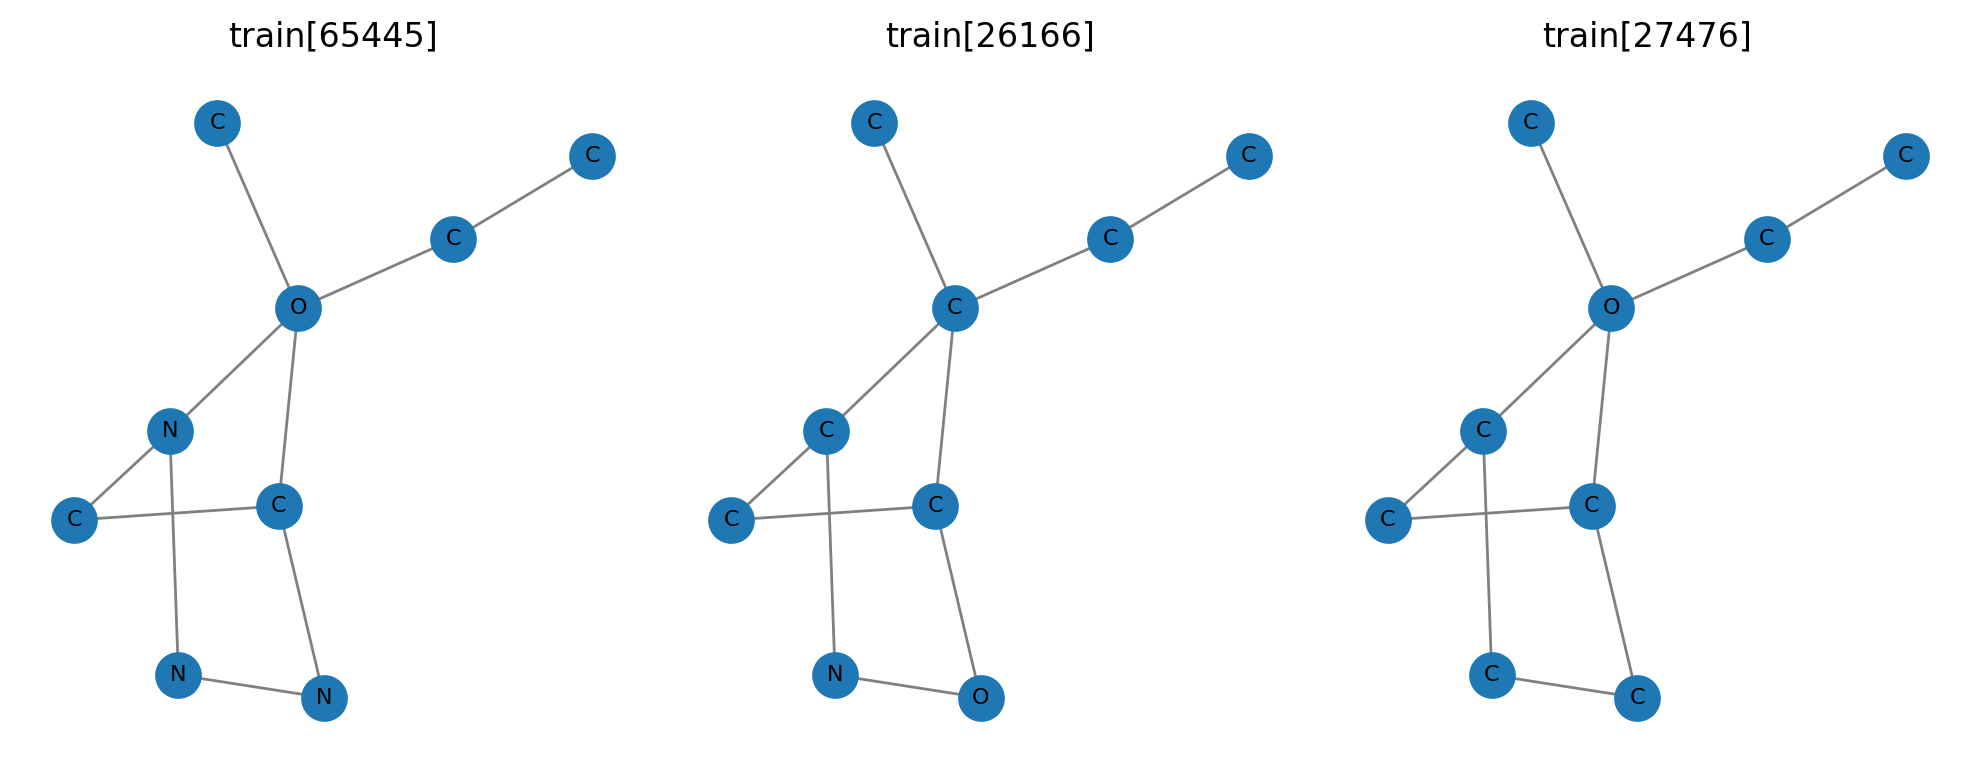

In [15]:
import matplotlib.pyplot as plt
import networkx as nx

def draw_molecule_from_sample(ds, idx):
    evec = ds[idx][0]; Lpad = ds[idx][-1][0]; n = int(ds[idx][-2]); edge_feat = ds[idx][4]
    # L = Lpad[:n,:n].cpu().numpy()
    # A = -L.copy(); np.fill_diagonal(A, 0.0)
    # A = (A > 0).astype(float)
    ###
    A = train_set[ii][-1][0][:n, :n].cpu().numpy()
    # L = train_set[ii][-3][:n, :n]
    # A = (-L).cpu().numpy(); np.fill_diagonal(A, 0.0)
    ###
    evu, _ = ds.unscale_xy(evec, ds[idx][1])
    node_labels = evu[:n, K:].argmax(-1).cpu().numpy()  # 0..3
    G = nx.from_numpy_array(A)
    pos = nx.kamada_kawai_layout(G)
    nx.draw(G, pos, node_size=250, edge_color="gray")
    nx.draw_networkx_labels(G, pos, labels={i: ATOM_MAP[int(node_labels[i])] for i in range(n)}, font_size=8)
    plt.axis('off')

plt.figure(figsize=(10,4))
for j, idx in enumerate(np.random.choice(len(train_set), size=3, replace=False)):
    plt.subplot(1,3,j+1); draw_molecule_from_sample(train_set, int(idx)); plt.title(f"train[{int(idx)}]")
plt.tight_layout(); plt.show()


In [16]:
def orth_err(phi, emask):
    k = min(K, phi.shape[1])
    E = emask[:k].float()
    Phi = phi[:, :k] * E[None, :]
    G = Phi.T @ Phi
    I = torch.diag(E)  # identity on active dims
    return torch.norm(G - I, p='fro').item() / max(1, E.sum().item())

L = train_set[0][-3][:n,:n]
float(L.diag().mean()), float(L.diag().std())  # ≈ (1.0, small) → normalized


(2.222222328186035, 0.9718253016471863)

In [17]:
def get_qm9_graph(ds, i):
    n = int(ds[i][-2])
    A = ds[i][-1][0][:n,:n].cpu().numpy()    # adjacency
    X = ds[i][0][:n, K:]                     # one-hot atom types
    E = ds[i][4][:n,:n].cpu()                # edge features (bond types)
    return A, X, E

def to_rdkit(A, X, E):
    from rdkit import Chem
    ATOM = {0:'C',1:'N',2:'O',3:'F'}
    BOND = [Chem.rdchem.BondType.SINGLE,
            Chem.rdchem.BondType.DOUBLE,
            Chem.rdchem.BondType.TRIPLE]
    mol = Chem.RWMol()
    idx = [mol.AddAtom(Chem.Atom(ATOM[int(x.argmax().item())])) for x in X]
    N = A.shape[0]
    for i in range(N):
        for j in range(i+1, N):
            if A[i,j] > 0.5:
                bt = int(E[i,j].argmax().item())
                mol.AddBond(i, j, BOND[bt])
    return mol.GetMol()


## Diffusion

In [ ]:
# === Diffusion training (QM9) — no wandb, saves + CSV logs ===
import argparse
import os
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import CSVLogger
from torch.utils.data import DataLoader

from dataset.load_data_generated import LaplacianDatasetNX
from models.diffusion import SpectralDiffusion

# folders (use your existing EXP/CKPT/LOGS)
CKPT_DIF = CKPT / "diffusion"
CKPT_DIF.mkdir(parents=True, exist_ok=True)
LOGS_DIF = LOGS / "diffusion"
LOGS_DIF.mkdir(parents=True, exist_ok=True)

# ----- hyperparameters (edit here) -----
args = argparse.Namespace(
    # data
    dataset="qm9",
    k=16,
    smallest=False,
    scaler="standard",
    # model
    latent_dim=256,
    layers=6,
    # optim
    batch_size=256,
    lr=1e-4,
    max_epochs=300,                 # 
    # logging cadence (PL 1.8: steps)
    val_check_interval=50000,
    log_every_n_steps=200,
)

# ----- datasets / loaders -----
ds_stem = str(REPO / "data" / args.dataset)
train_set = LaplacianDatasetNX(args.dataset, ds_stem, point_dim=args.k,
                               smallest=args.smallest, split="train_train",
                               scaler=args.scaler, nodefeatures=True, device="cpu")
valid_set = LaplacianDatasetNX(args.dataset, ds_stem, point_dim=args.k,
                               smallest=args.smallest, split="train_val",
                               scaler=args.scaler, nodefeatures=True, device="cpu")

# (optional) cache heavy extras once
train_set.get_extra_data(False)

NUM_WORKERS = min(8, (os.cpu_count() or 2) // 2)
train_loader = DataLoader(train_set, batch_size=args.batch_size,
                          shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(valid_set, batch_size=len(valid_set),
                          shuffle=False, num_workers=0, pin_memory=False)

# repo model expects feature_size in hparams
args.feature_size = train_set[0][0].shape[-1] - args.k

# ----- model -----
model = SpectralDiffusion(args)

# ----- logging + checkpoints (no wandb) -----
csv_logger = CSVLogger(save_dir=str(LOGS_DIF), name="run")
ckpt_cb = ModelCheckpoint(
    dirpath=str(CKPT_DIF),
    filename="diffusion-{epoch:03d}-{loss:.4f}",
    save_last=True, save_top_k=1,
    monitor="loss", mode="min",
)
early_cb = EarlyStopping(monitor="loss", patience=10, mode="min")

# ----- trainer -----
trainer = pl.Trainer(
    accelerator=("gpu" if torch.cuda.is_available() else "cpu"),
    devices=1,
    logger=csv_logger,                   # writes metrics.csv
    default_root_dir=str(EXP),
    callbacks=[ckpt_cb, early_cb],
    log_every_n_steps=args.log_every_n_steps,
    check_val_every_n_epoch=None,
    val_check_interval=args.val_check_interval,
    max_epochs=args.max_epochs,
    enable_progress_bar=True,
    num_sanity_val_steps=0,
)

print("starting diffusion training…")
trainer.fit(model, train_loader, valid_loader)
print("done.")
print("last ckpt:", ckpt_cb.last_model_path)
print("best ckpt:", ckpt_cb.best_model_path)

# where the plain-text logs land
print("metrics CSV:", os.path.join(csv_logger.log_dir, "metrics.csv"))


/nfs/team361/mv11/.venvs/ggsd/lib/python3.10/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 6, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/nfs/team361/mv11/.venvs/ggsd/lib/python3.10/site-packages/pytorch_lightning/core/optimizer.py:329: RuntimeWarning: The lr scheduler dict contains the key(s) ['interval', 'frequency'], but the keys will be ignored. You need to call `lr_scheduler.step()` manually in manual optimization.
  rank_zero_warn(

  | Name      | Type      

starting diffusion training…


/nfs/team361/mv11/.venvs/ggsd/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, val_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 192 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

/nfs/team361/mv11/.venvs/ggsd/lib/python3.10/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 6, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
import pandas as pd, matplotlib.pyplot as plt, os
log_csv = os.path.join(csv_logger.log_dir, "metrics.csv")
df = pd.read_csv(log_csv)
ax = df.groupby("epoch").mean(numeric_only=True)[["loss","lr"]].plot(secondary_y="lr", marker="o", grid=True, figsize=(7,3.5))
plt.title("Diffusion training"); plt.show()
